# Basic Example using MOGPTK

Basics of defining, fitting, and plotting results of MOGPTK model.

In [ ]:
import numpy as np 
import torch
import mogptk

torch.manual_seed(1);

## Toy dataset

Four noise sinusoidal signals, all with same frequency but different phases and delays.

1. Sinusoid with no delay and phase zero.

$$Y_1 \mid t \sim \mathcal{N}\left(\sin(6t), 0.2^2\right)$$

2. Sinusoid with phase shift of -2, no delay.

$$Y_2 \mid t \sim \mathcal{N}\left(\sin(6t + 2), 0.2^2\right)$$

3. Sum of sinusoids with no delays or phase shifts.

$$Y_3 \mid t \sim \mathcal{N}\left(\sin(6t) - \sin(0.4t), 0.2^2\right)$$

4. Increased amplitude with zero phase shift but delayed by 2  

$$Y_4 \mid t \sim \mathcal{N}\left(3\sin(6(t-2)), 0.3^2\right)$$

In [56]:
n_points = 100
t = np.linspace(0.0, 6.0, n_points)

y1 = np.sin(6.0*t) + 0.2*np.random.normal(size=len(t))
y2 = np.sin(6.0*t + 2.0) + 0.2*np.random.normal(size=len(t))
y3 = np.sin(6.0*t) - np.sin(4.0*t) + 0.2*np.random.normal(size=len(t)) 
y4 = 3.0*np.sin(6.0 * (t-2.0)) + 0.3*np.random.normal(size=len(t))

# create dataset
dataset = mogptk.DataSet(
    mogptk.Data(t, y1, name='Sinusoid'),
    mogptk.Data(t, y2, name='Phase shifted'),
    mogptk.Data(t, y3, name='2 sinusoids'),
    mogptk.Data(t, y4, name='Amplified and delayed')
)

# remove 40% randomly
for data in dataset:
    data.remove_randomly(pct=0.4)

# remove second half of the first channel
dataset[0].remove_range(start=2.0)

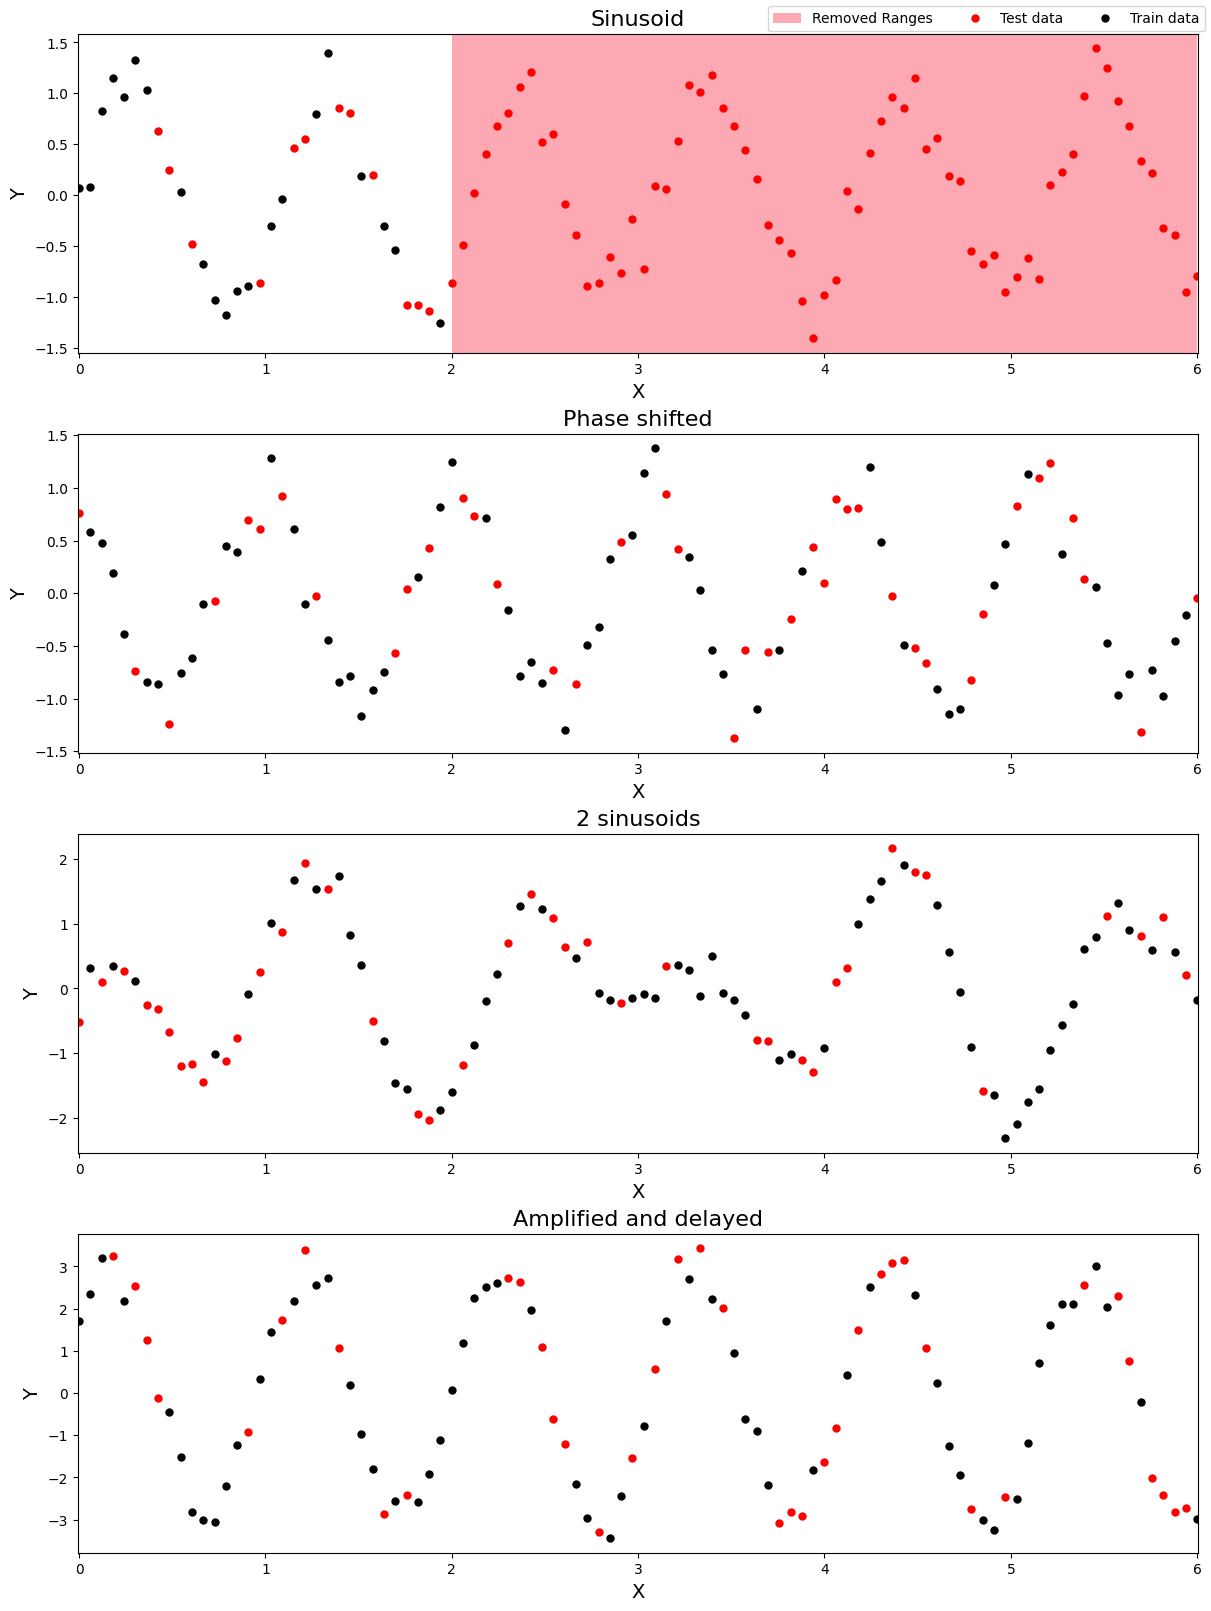

In [57]:
dataset.plot();

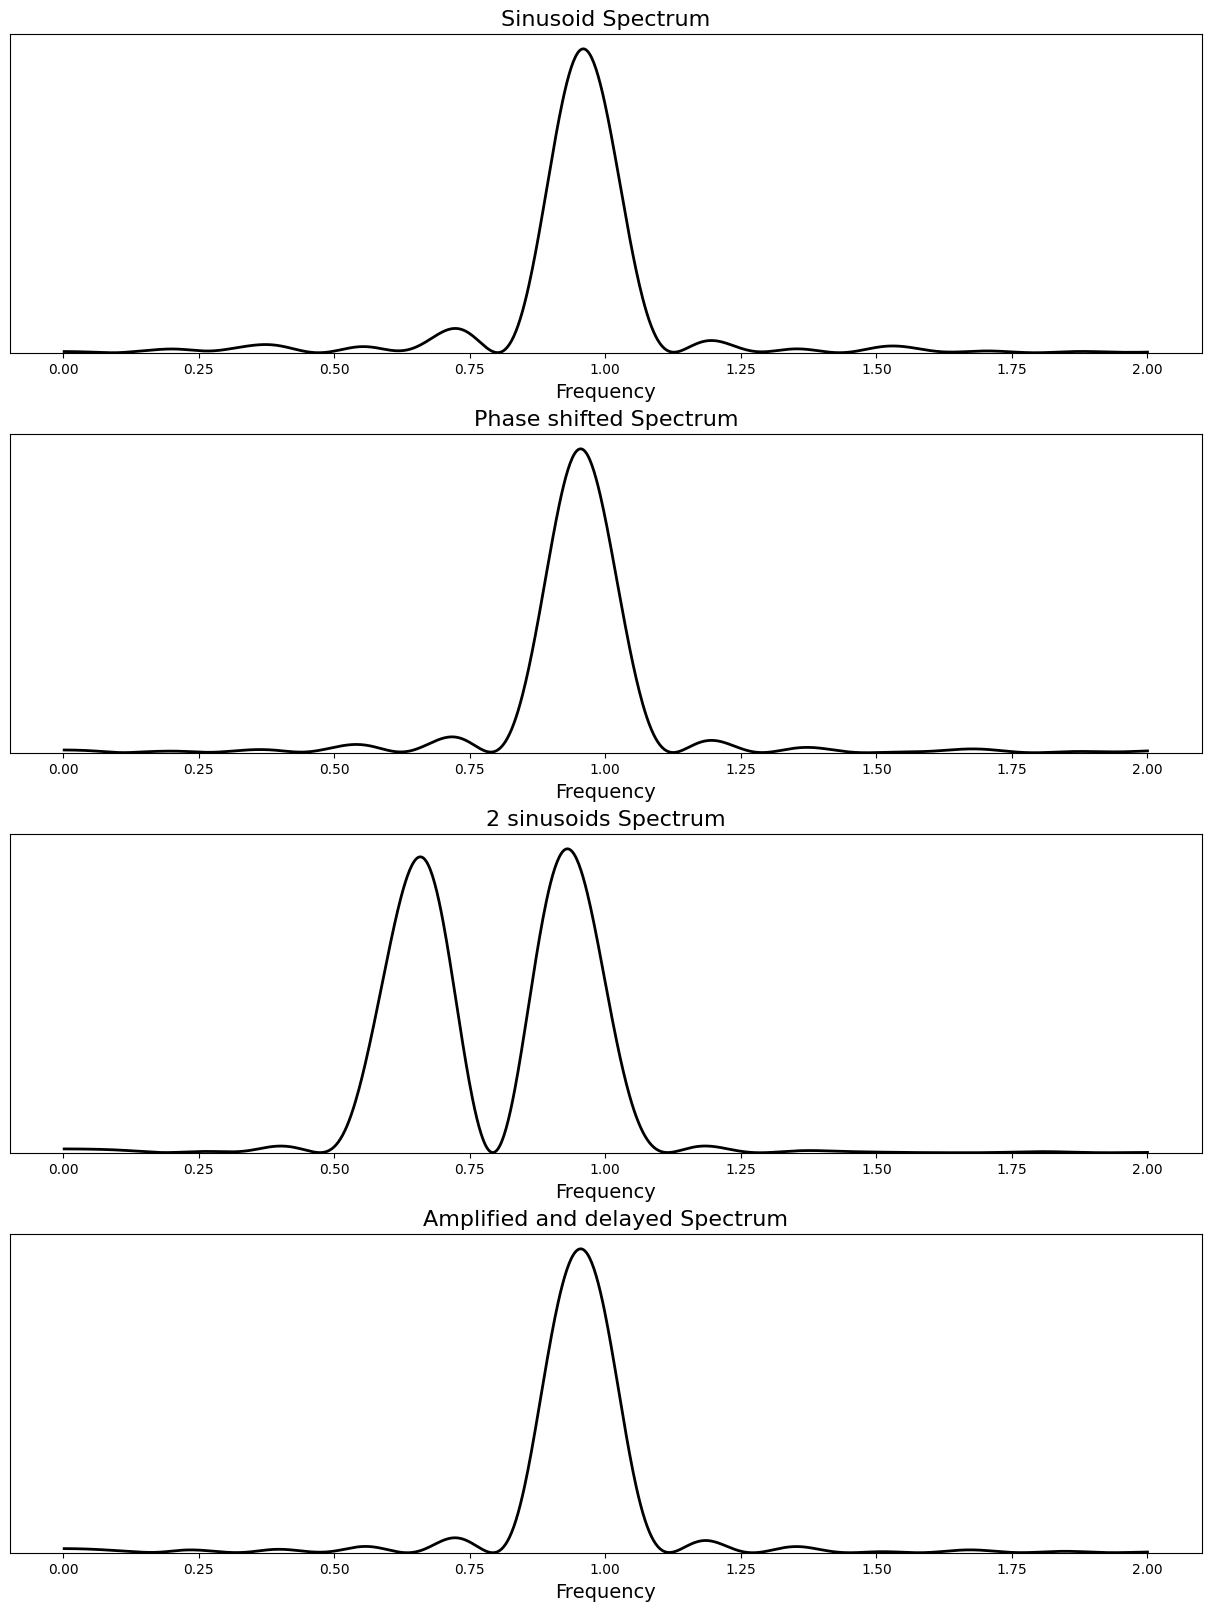

In [58]:
# LS periodogram
dataset.plot_spectrum(maxfreq=2);

In [59]:
# create model, uncomment for different kernels 
model = mogptk.MOSM(dataset, Q=2)
# model = mogptk.CSM(dataset, Q=2)
# model = mogptk.SM_LMC(dataset, Q=2)
# model = mogptk.CONV(dataset, Q=2)

# initialize parameters of kernel using LombScargle
model.init_parameters(method='LS', iters=500)

model.print_parameters()

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[11.72343688 4.74764503] [10.16351981 2.97806926] [10.74391253 10.57281779] [29.16438679 9.99666773]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 8.250000000000007]",[[[0.94471947] [2.60808581]] [[0.95462046] [3.45132013]] [[0.93564356] [0.65924092]] [[0.95462046] [0.71864686]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.03183477] [0.02995545]] [[0.00359404] [0.00395721]] [[0.00407905] [0.00366845]] [[0.003689 ] [0.00131565]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[0.] [0.]] [[0.] [0.]] [[0.] [0.]] [[0.] [0.]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[0. 0.] [0. 0.] [0. 0.] [0. 0.]]
GaussianLikelihood.scale,"[1e-08, ∞)",[0.84525113 0.72352965 1.04895631 2.08506696]


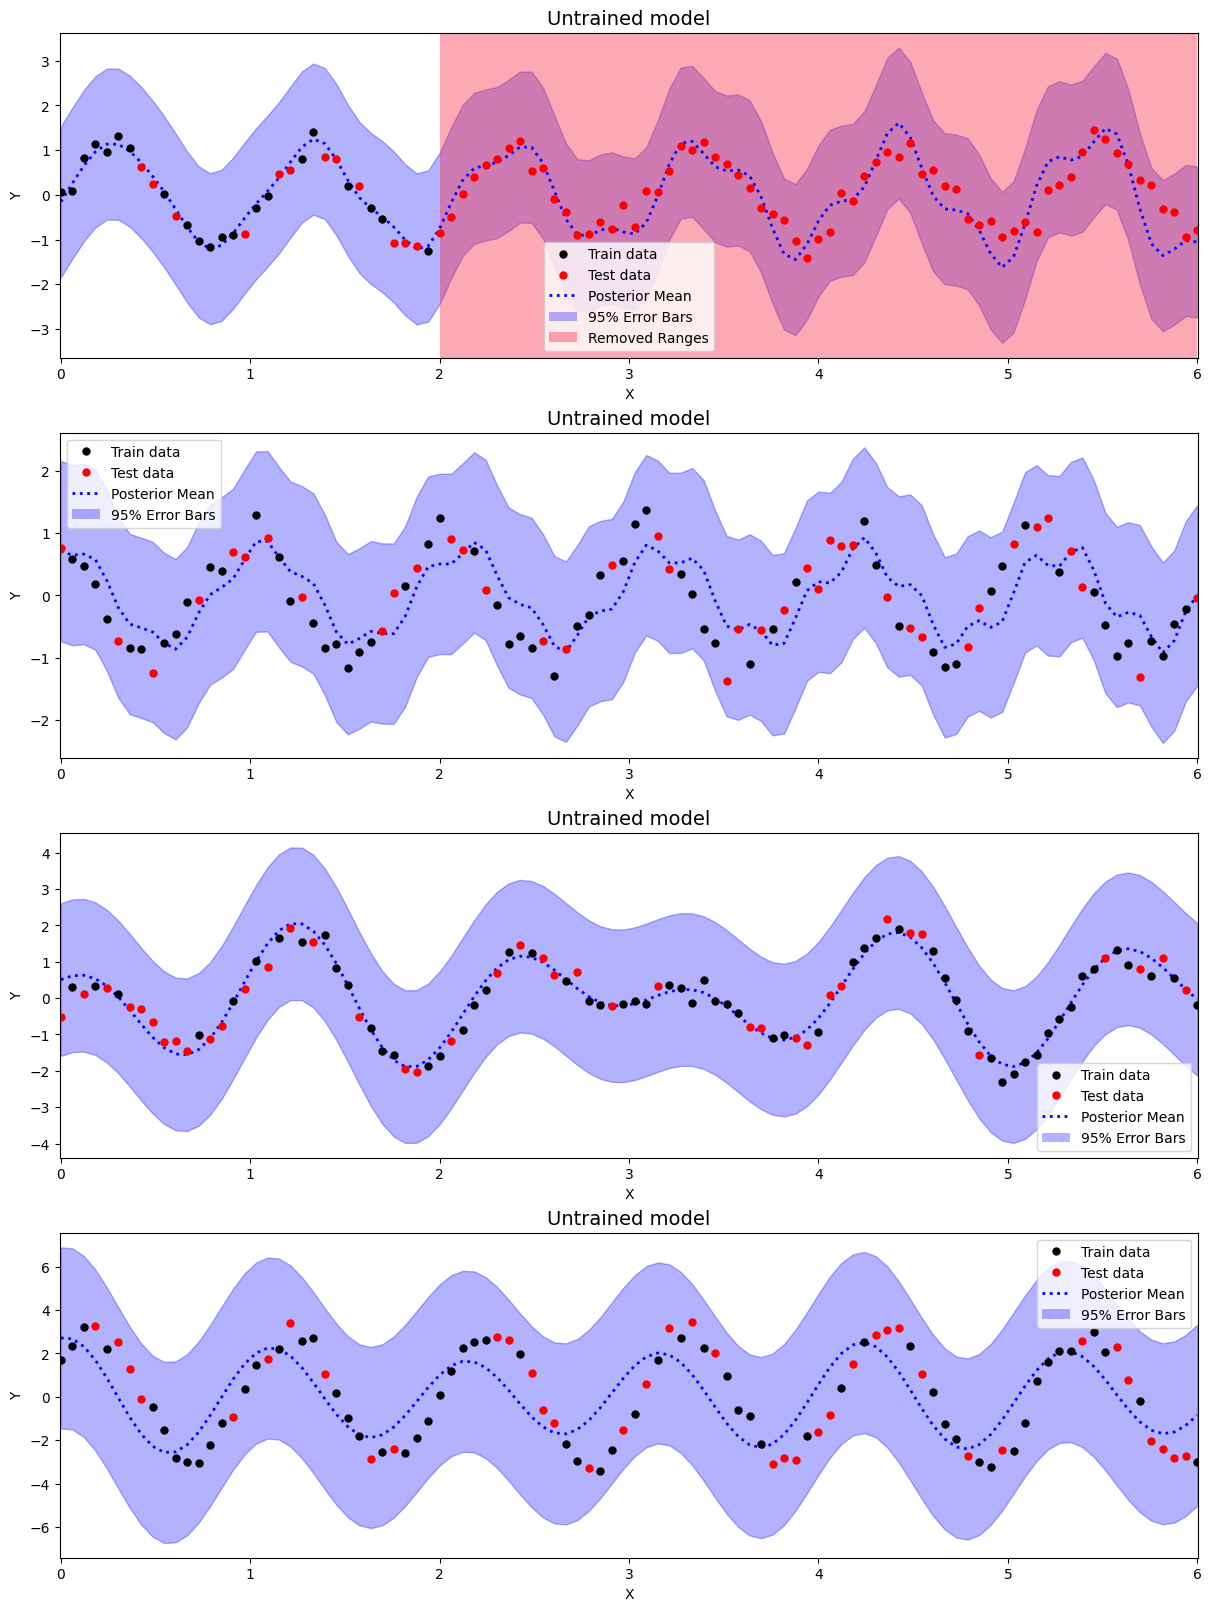

In [60]:
# plot the prediction with the untrained model
model.plot_prediction(title='Untrained model');

Starting optimization using Adam
‣ Model: Exact
  ‣ Kernel: MultiOutputSpectralMixtureKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 4
‣ Parameters: 44
‣ Training points: 201
‣ Iterations: 1000
     0/1000   0:00:00  loss=     281.384  error=    0.537949 (warmup)
   492/1000   0:00:10  loss=     81.8679  error=    0.233215
  1000/1000   0:00:19  loss=     2.77265  error=    0.217959
Optimization finished in 19.741 seconds


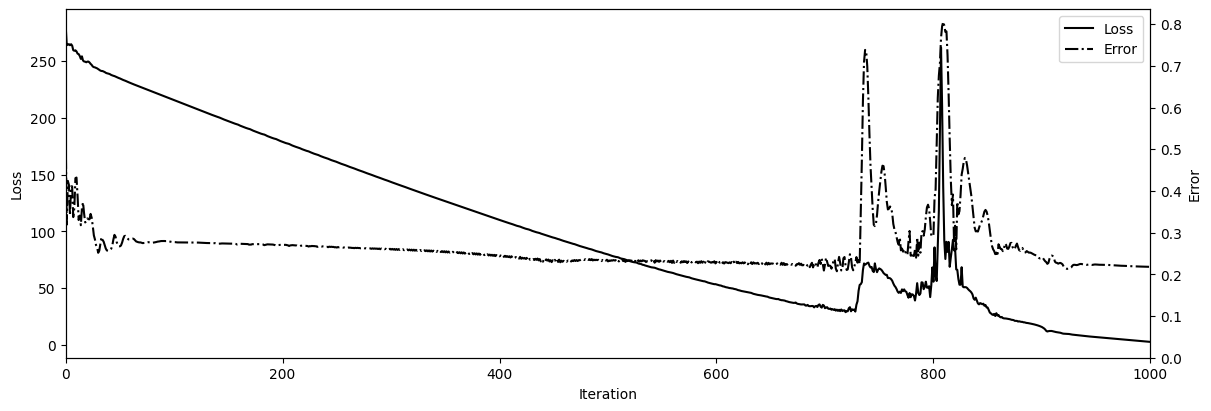

In [61]:
# Train the model
model.train(method='Adam', lr=0.02, iters=1000, plot=True, error='MAE', verbose=True);

In [62]:
model.print_parameters()

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[ 4.62797745 0.87999327] [ 4.97600199 0.57971043] [ 5.03946524 2.90656067] [14.85326177 2.72049016]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 8.250000000000007]",[[[0.95422944] [2.67745716]] [[0.95525638] [3.41560317]] [[0.95462452] [0.63195449]] [[0.95513863] [0.95372299]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.0066248 ] [0.00611824]] [[0.00397617] [0.00085076]] [[0.00396117] [0.00076156]] [[0.00317996] [0.00028747]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[-5.37448491e-01] [ 3.00042383e-82]] [[-4.06252575e-02] [-3.00042383e-82]] [[-2.62746642e-01] [-2.05437957e-02]] [[ 3.17564835e-01] [ 2.05437957e-02]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[ 5.56757399e-02 8.94869410e-83] [-1.01804346e-01 -8.94869410e-83] [-2.00036572e-01 -2.10312936e-02] [ 3.19071927e-01 2.10312936e-02]]
GaussianLikelihood.scale,"[1e-08, ∞)",[0.1935951 0.17426684 0.210465 0.40382402]


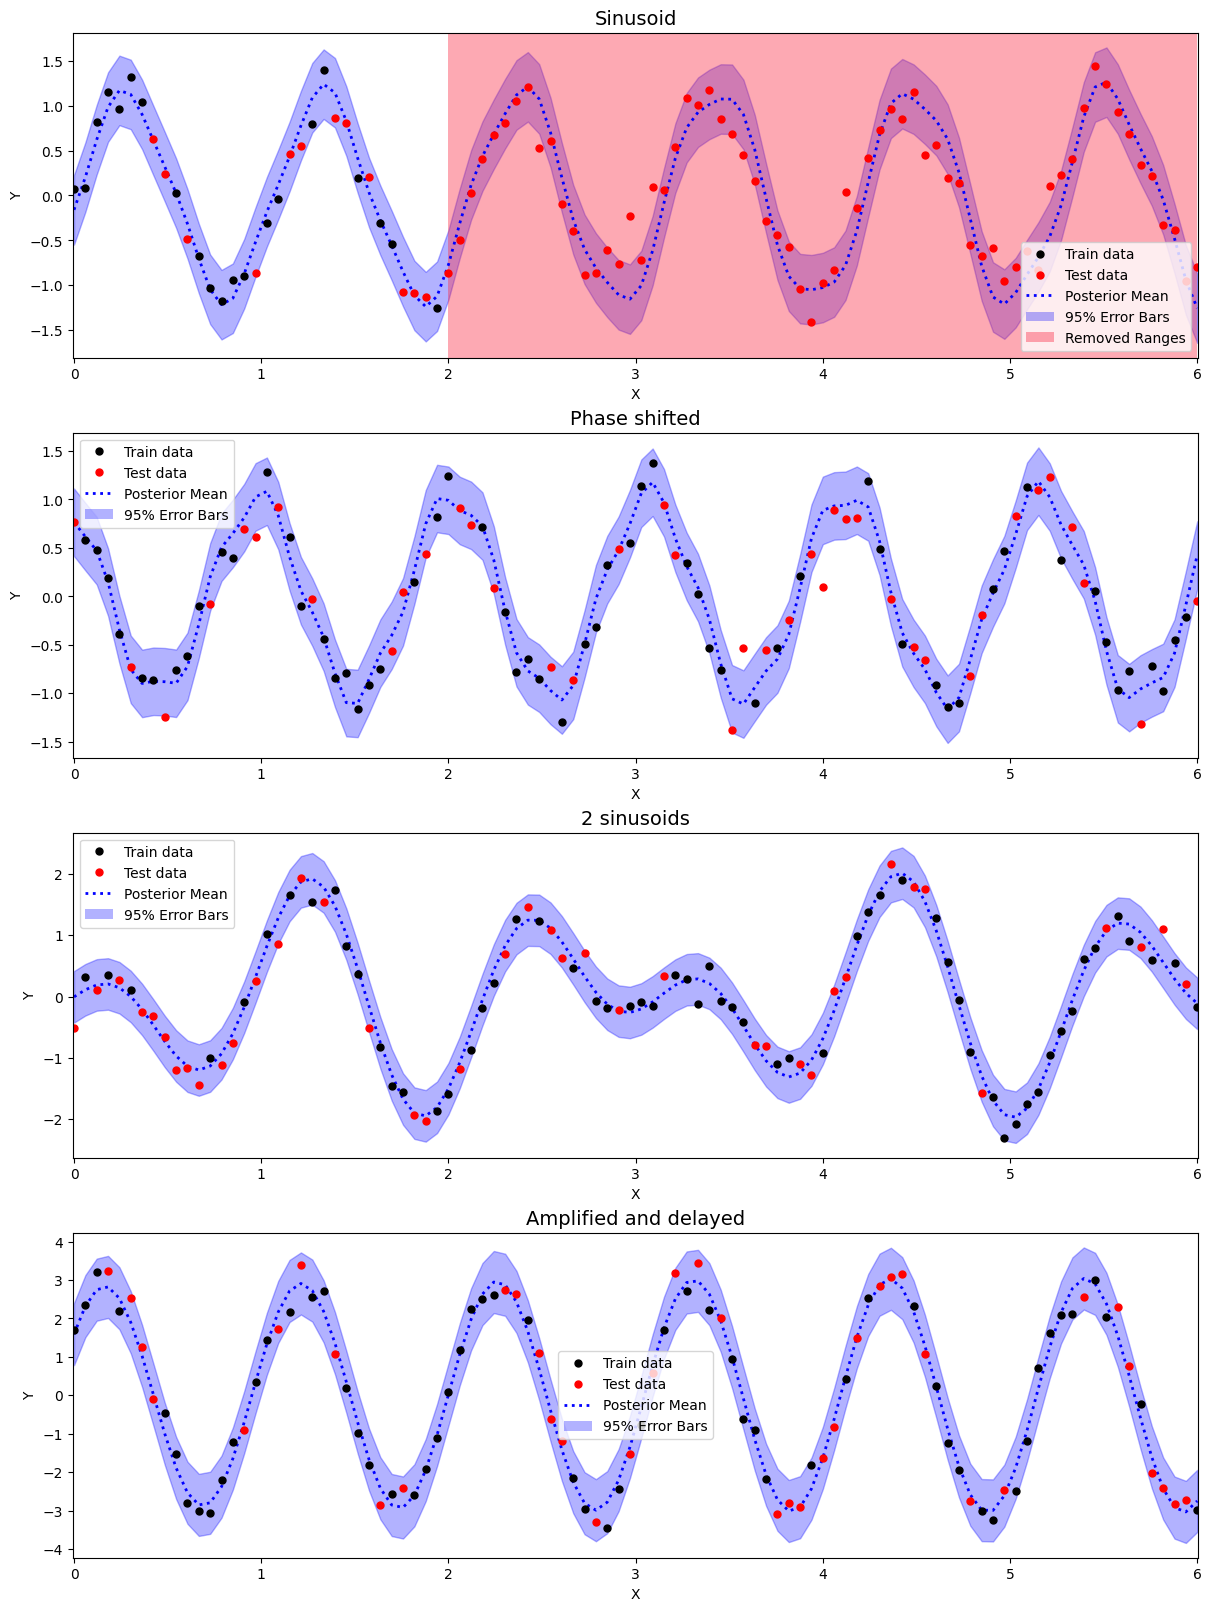

In [63]:
model.plot_prediction();

In [64]:
# prediction outside training range
# we use the same time for all the channels
t_pred = np.linspace(6.0, 10.0, 100)
x_pred = [t_pred for i in range(len(dataset))]
dataset.set_prediction_data(x_pred)

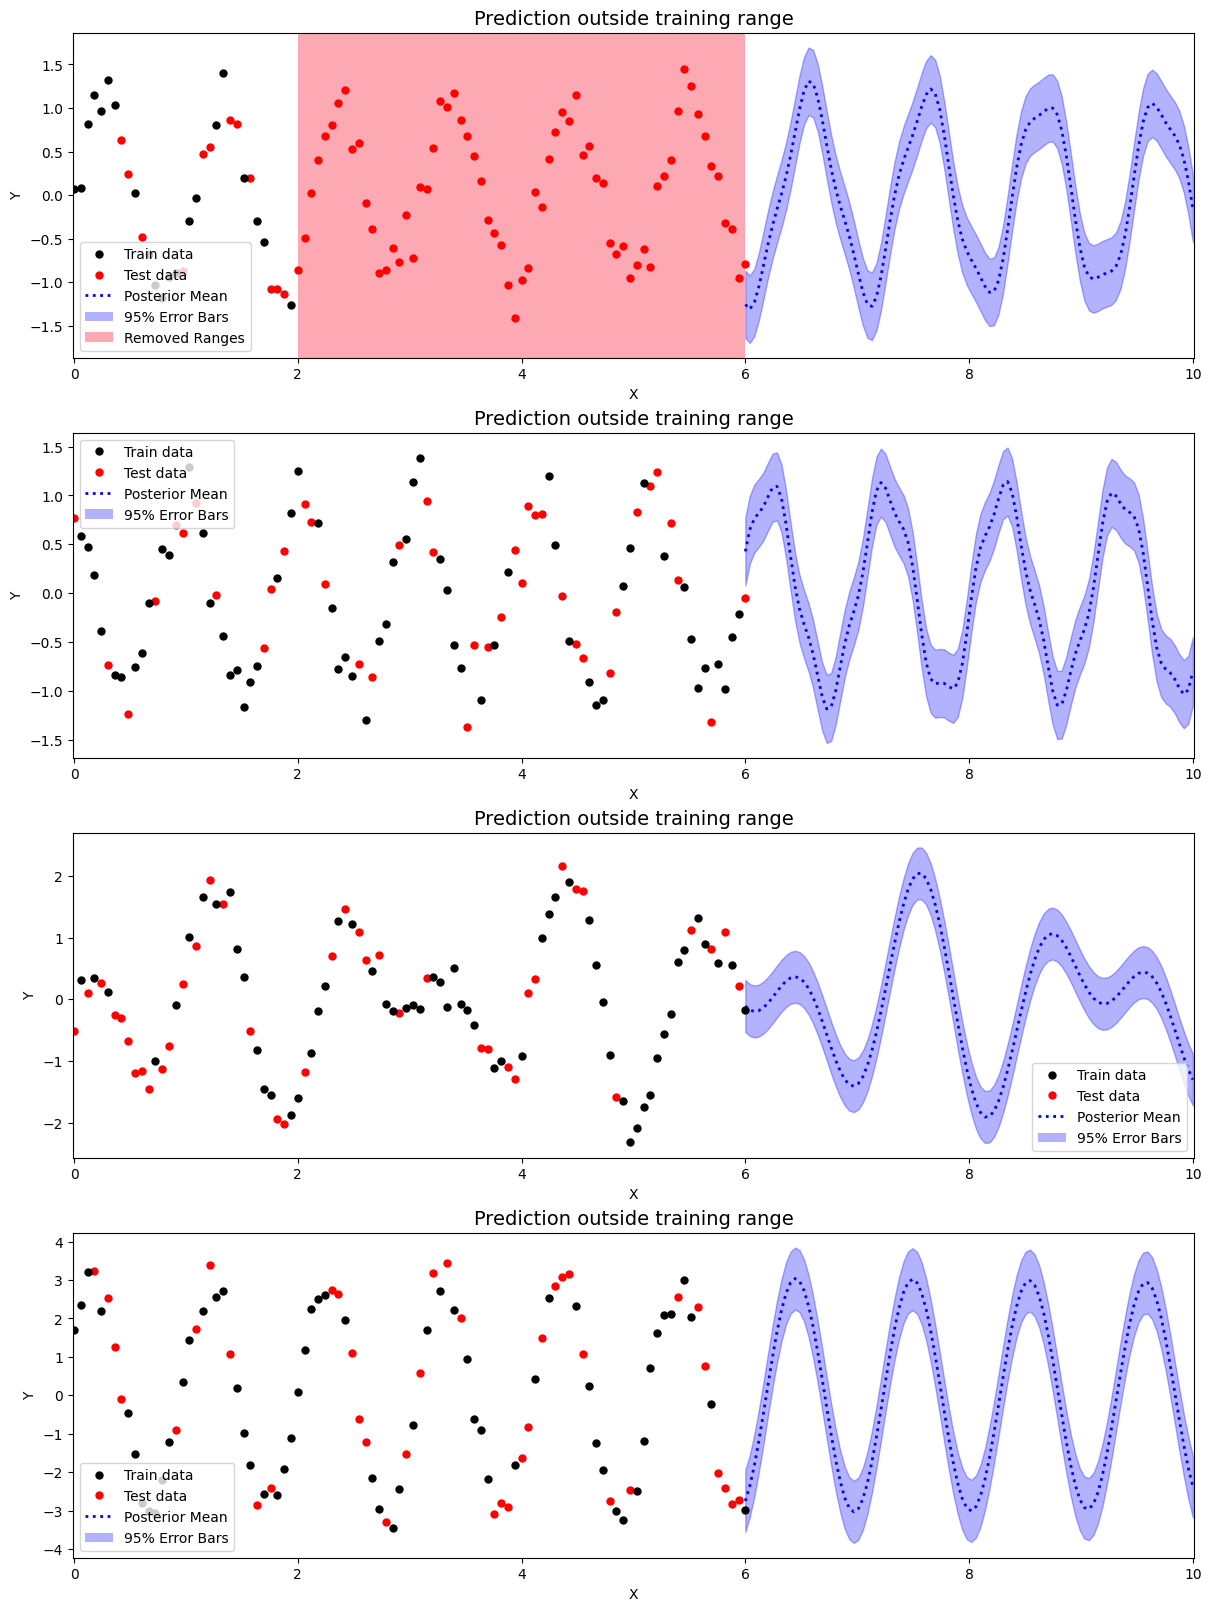

In [65]:
model.plot_prediction(title='Prediction outside training range');